In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

print(os.listdir("../input"))



['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
# Notebook magics removed for .py/Kaggle script compatibility.
# (They would error outside Jupyter.)
pass



In [3]:
# fastai v2 imports (the original code used fastai v1 APIs)
from fastai.vision.all import *

import fastai

print("fastai version:", fastai.__version__)



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

fastai version: 2.8.5


In [4]:
# Use the actual competition folder under ../input
path = Path("../input/aerial-cactus-identification")
assert path.exists(), f"Dataset path not found: {path}"

train_csv = path / "train.csv"
sample_sub_csv = path / "sample_submission.csv"
train_img_dir = path / "train"  # contains images directly
test_img_dir = path / "test"  # contains images directly

train_df = pd.read_csv(train_csv)
train_df.head()



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [5]:
test_df = pd.read_csv(sample_sub_csv)
print(test_df.shape)
test_df.head()



(3325, 2)


,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.5
1,134f04305c795d6d202502c2ce3578f3.jpg,0.5
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.5
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.5
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.5


In [6]:
# fastai v2 DataLoaders from dataframe (preserves the same core idea: aug + 32x32)
# Also set a seed for reproducibility (score-neutral/stability).
set_seed(42, reproducible=True)

item_tfms = Resize(32)
batch_tfms = aug_transforms(
    do_flip=True,
    flip_vert=True,
    max_rotate=10.0,
    max_zoom=1.1,
    max_lighting=0.2,
    max_warp=0.2,
    p_affine=0.75,
    p_lighting=0.75,
)

dls = ImageDataLoaders.from_df(
    train_df,
    path=train_img_dir,
    fn_col="id",
    label_col="has_cactus",
    valid_pct=0.2,
    seed=42,
    bs=128,
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)



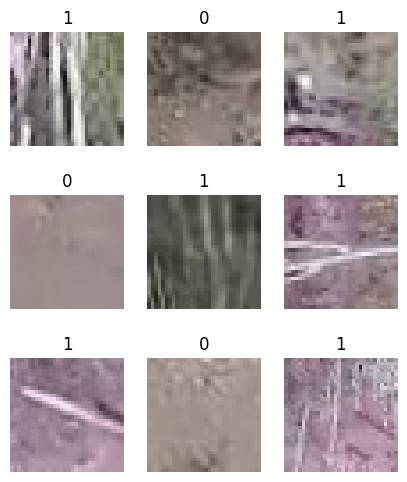

In [7]:
# Optional visualization (kept, but safe to run headless)
_ = dls.show_batch(max_n=9, figsize=(5, 6))



In [8]:
dls.vocab, dls.c



([0, 1], 2)

In [9]:
# Keep the same backbone (ResNet50) and a similar metric (error_rate).
# fastai v2 requires importing resnet50 from torchvision.
learn = vision_learner(dls, resnet50, metrics=error_rate, model_dir=Path("/tmp/model/"))



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 114MB/s]


ValueError: not enough values to unpack (expected 2, got 1)

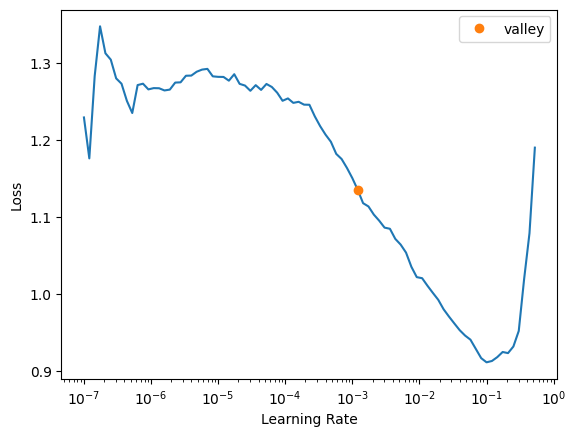

In [10]:
# lr_find can be slow; keep it but don't require interactive plotting.
lr_min, lr_steep = learn.lr_find()
print("lr_find:", lr_min, lr_steep)



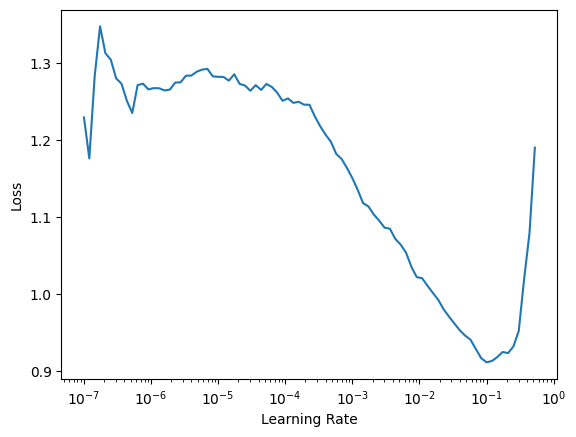

In [11]:
# Plotting is optional; kept for parity (will no-op in some environments)
try:
    learn.recorder.plot_lr_find()
except Exception as e:
    print("plot_lr_find skipped:", repr(e))



In [12]:
lr = 2.5e-3
learn.fit_one_cycle(5, lr)



epoch,train_loss,valid_loss,error_rate,time
0,0.669138,0.408666,0.134039,00:03
1,0.394449,0.246091,0.089947,00:04
2,0.287806,0.211201,0.083245,00:04
3,0.241401,0.259750,0.078307,00:04
4,0.218068,0.245681,0.078307,00:04


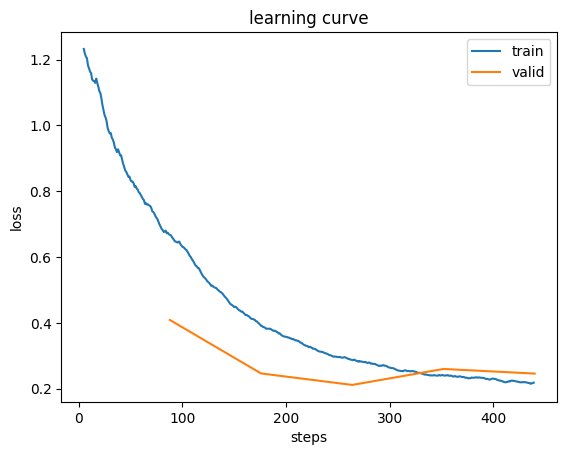

In [13]:
try:
    learn.recorder.plot_loss()
except Exception as e:
    print("plot_loss skipped:", repr(e))



In [14]:
learn.save("step-1")



Path('/tmp/model/step-1.pth')

In [15]:
learn.load("step-1")



ValueError: not enough values to unpack (expected 2, got 1)

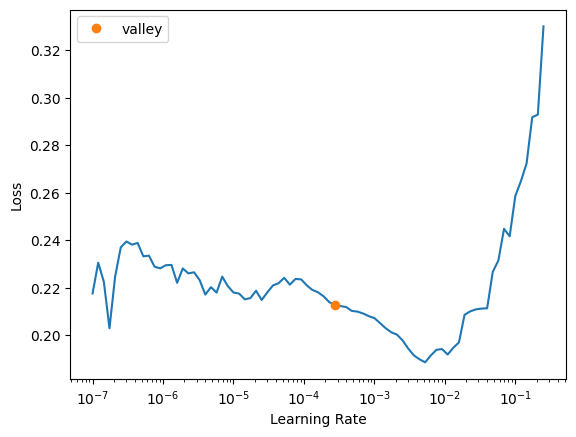

In [16]:
# fastai v2 freeze_to exists; keep the intent from the original notebook.
learn.freeze_to(1)
lr_min2, lr_steep2 = learn.lr_find()
print("lr_find (stage2):", lr_min2, lr_steep2)



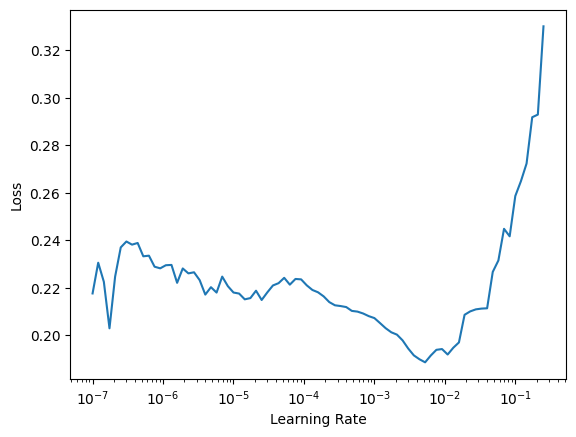

In [17]:
try:
    learn.recorder.plot_lr_find()
except Exception as e:
    print("plot_lr_find skipped:", repr(e))



In [18]:
learn.fit_one_cycle(5, lr_max=slice(3e-6, 1e-4))



epoch,train_loss,valid_loss,error_rate,time
0,0.215787,0.194678,0.069136,00:04
1,0.192094,0.180989,0.059965,00:03
2,0.176901,0.156928,0.058907,00:03
3,0.180652,0.149457,0.051852,00:03
4,0.164636,0.147128,0.053263,00:03


In [19]:
learn.save("step-2")



Path('/tmp/model/step-2.pth')

In [20]:
# Prepare solution frame with correct columns
solution = pd.DataFrame(columns=test_df.columns)
solution.head()



,id,has_cactus


In [21]:
# Efficient test prediction: create a test dataloader from filenames and get probabilities
test_files = [test_img_dir / fn for fn in test_df["id"].tolist()]
test_dl = dls.test_dl(test_files)

preds, _ = learn.get_preds(dl=test_dl)  # shape [n,2] for 2 classes
# Probability for class "1" (has_cactus=1). dls.vocab should be ['0','1'].
has_cactus_prob = preds[:, 1].cpu().numpy()

solution = pd.DataFrame({"id": test_df["id"].values, "has_cactus": has_cactus_prob})

# Sanity checks
assert solution.shape[0] == test_df.shape[0]
assert list(solution.columns) == ["id", "has_cactus"]

solution.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.987150
1,134f04305c795d6d202502c2ce3578f3.jpg,0.999939
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.968520
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.996638
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.978426


In [22]:
solution.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", solution.shape)
print(solution.head())

Wrote submission.csv with shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.987150
1  134f04305c795d6d202502c2ce3578f3.jpg    0.999939
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.968520
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.996638
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.978426
